# This notebook deals with the question

# **"Can we classify whether the plasma is currently in phase 0 or phase 1?"**

# Logistic Regression

Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedGroupKFold,
    GroupKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

import joblib

Settings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FILE_PATH = "/content/drive/MyDrive/Plasma Density Limit Dataset/Open_Density_Limit_Dataset.csv"

RANDOM_STATE = 42

N_OUTER_SPLITS = 5
N_INNER_SPLITS = 4

# Logistic regression hyperparameters
C_VALUES = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

CLASS_WEIGHTS = [
    None,
    "balanced"
]

Load Data

In [ ]:
df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("DATASET")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

DATASET
Shape: (264385, 9)

Columns:
['discharge_ID', 'time', 'density_limit_phase', 'density', 'elongation', 'minor_radius', 'plasma_current', 'toroidal_B_field', 'triangularity']


,discharge_ID,time,density_limit_phase,density,elongation,minor_radius,plasma_current,toroidal_B_field,triangularity
0,1000606012,0.26,0,1.068483,1.596838,0.215675,0.732045,5.375454,0.366888
1,1000606012,0.27,0,1.072965,1.624681,0.214933,0.742422,5.375454,0.379412
2,1000606012,0.28,0,1.077447,1.652525,0.214190,0.752798,5.375454,0.391936
3,1000606012,0.29,0,1.126277,1.662114,0.212518,0.760581,5.375454,0.392512
4,1000606012,0.30,0,1.175108,1.671703,0.210845,0.768363,5.375454,0.393087


Define variables

In [ ]:
FEATURES = [
    "density",
    "elongation",
    "minor_radius",
    "plasma_current",
    "toroidal_B_field",
    "triangularity"
]

TARGET = "density_limit_phase"

GROUP = "discharge_ID"

TIME = "time"

Basic Validation

In [ ]:
required_columns = FEATURES + [TARGET, GROUP, TIME]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nAll required columns are present.")


All required columns are present.


Clean the data

In [ ]:
data = df[required_columns].copy()

# Convert target to numeric
data[TARGET] = pd.to_numeric(
    data[TARGET],
    errors="coerce"
)

# Convert features to numeric
for col in FEATURES:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[TIME] = pd.to_numeric(
    data[TIME],
    errors="coerce"
)

# Remove missing values
before = len(data)

data = data.dropna()

after = len(data)

print(f"\nRows before cleaning: {before}")
print(f"Rows after cleaning : {after}")
print(f"Rows removed        : {before - after}")


Rows before cleaning: 264385
Rows after cleaning : 264385
Rows removed        : 0


Check Target

In [ ]:
unique_targets = sorted(
    data[TARGET].unique()
)

print("\nTarget values:", unique_targets)

if not set(unique_targets).issubset({0, 1}):
    raise ValueError(
        "Target contains values other than 0 and 1."
    )

print("\nTarget distribution:")
print(data[TARGET].value_counts())

print("\nTarget proportion:")
print(
    data[TARGET].value_counts(
        normalize=True
    )
)


Target values: [np.int64(0), np.int64(1)]

Target distribution:
density_limit_phase
0    260787
1      3598
Name: count, dtype: int64

Target proportion:
density_limit_phase
0    0.986391
1    0.013609
Name: proportion, dtype: float64


Discharge Level Information

In [ ]:
n_discharge = data[GROUP].nunique()

print("\nNumber of discharges:", n_discharge)

# Number of discharges containing both classes
class_per_discharge = (
    data.groupby(GROUP)[TARGET]
    .nunique()
)

print(
    "Discharges containing both classes:",
    (class_per_discharge == 2).sum()
)

print(
    "Discharges containing only one class:",
    (class_per_discharge == 1).sum()
)


Number of discharges: 2333
Discharges containing both classes: 73
Discharges containing only one class: 2260


Features / Target / Group

In [ ]:
X = data[FEATURES].copy()

y = data[TARGET].astype(int).copy()

groups = data[GROUP].copy()

Check for Discharge Leakage

In [ ]:
print("\n" + "=" * 70)
print("DISCHARGE LEAKAGE CHECK")
print("=" * 70)

# We will demonstrate that every fold keeps complete
# discharges together.

sgkf_check = StratifiedGroupKFold(
    n_splits=N_OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

for fold, (train_idx, test_idx) in enumerate(
    sgkf_check.split(X, y, groups),
    start=1
):

    train_groups = set(
        groups.iloc[train_idx]
    )

    test_groups = set(
        groups.iloc[test_idx]
    )

    overlap = train_groups.intersection(
        test_groups
    )

    print(
        f"Fold {fold}: "
        f"train discharges={len(train_groups)}, "
        f"test discharges={len(test_groups)}, "
        f"overlap={len(overlap)}"
    )

    if overlap:
        raise RuntimeError(
            "DISCHARGE LEAKAGE DETECTED!"
        )

print("\n✓ No discharge leakage.")


DISCHARGE LEAKAGE CHECK
Fold 1: train discharges=1869, test discharges=464, overlap=0
Fold 2: train discharges=1866, test discharges=467, overlap=0
Fold 3: train discharges=1868, test discharges=465, overlap=0
Fold 4: train discharges=1865, test discharges=468, overlap=0
Fold 5: train discharges=1864, test discharges=469, overlap=0

✓ No discharge leakage.


Model

In [ ]:
pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "logistic",
        LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            random_state=RANDOM_STATE
        )
    )
])

Hyperparameter Grid

In [ ]:
param_grid = {
    "logistic__C": C_VALUES,
    "logistic__class_weight": CLASS_WEIGHTS
}

Outer CV

In [ ]:
outer_cv = StratifiedGroupKFold(
    n_splits=N_OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

Out-of-Fold Storage

In [ ]:
oof_probability = np.full(
    len(data),
    np.nan
)

oof_prediction = np.full(
    len(data),
    np.nan
)

fold_results = []

best_models = []

Nested Cross Validation

In [ ]:
# ============================================================
# 15. NESTED CROSS-VALIDATION
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups),
    start=1
):

    print("\n" + "-" * 60)
    print(f"OUTER FOLD {fold}")
    print("-" * 60)

    # --------------------------------------------------------
    # Outer training/test split
    # --------------------------------------------------------

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]

    # --------------------------------------------------------
    # Inner cross-validation
    # --------------------------------------------------------

    inner_cv = StratifiedGroupKFold(
        n_splits=N_INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + fold
    )

    # --------------------------------------------------------
    # Grid search INSIDE the outer fold
    # --------------------------------------------------------

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="average_precision",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    # IMPORTANT:
    # groups_train is passed to the inner CV
    grid.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    # Best model selected using ONLY the outer
    # training data
    best_model = grid.best_estimator_

    print("Best parameters:")
    print(grid.best_params_)

    print(
        "Best inner PR-AUC:",
        round(grid.best_score_, 4)
    )

    # --------------------------------------------------------
    # Evaluate on completely untouched outer test fold
    # --------------------------------------------------------

    probability = best_model.predict_proba(
        X_test
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    # Store out-of-fold predictions
    oof_probability[test_idx] = probability
    oof_prediction[test_idx] = prediction

    # --------------------------------------------------------
    # Calculate outer-fold metrics
    # --------------------------------------------------------

    fold_auc = roc_auc_score(
        y_test,
        probability
    )

    fold_pr_auc = average_precision_score(
        y_test,
        probability
    )

    fold_accuracy = accuracy_score(
        y_test,
        prediction
    )

    fold_balanced_accuracy = balanced_accuracy_score(
        y_test,
        prediction
    )

    fold_precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    fold_recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    fold_f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        prediction,
        labels=[0, 1]
    ).ravel()

    fold_specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    fold_brier = brier_score_loss(
        y_test,
        probability
    )

    fold_results.append({
        "fold": fold,
        "ROC_AUC": fold_auc,
        "PR_AUC": fold_pr_auc,
        "Accuracy": fold_accuracy,
        "Balanced_Accuracy": fold_balanced_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1": fold_f1,
        "Specificity": fold_specificity,
        "Brier": fold_brier
    })

    print(f"ROC-AUC          : {fold_auc:.4f}")
    print(f"PR-AUC            : {fold_pr_auc:.4f}")
    print(f"Accuracy          : {fold_accuracy:.4f}")
    print(f"Balanced accuracy : {fold_balanced_accuracy:.4f}")
    print(f"Precision         : {fold_precision:.4f}")
    print(f"Recall            : {fold_recall:.4f}")
    print(f"F1                : {fold_f1:.4f}")
    print(f"Specificity       : {fold_specificity:.4f}")
    print(f"Brier score       : {fold_brier:.4f}")


------------------------------------------------------------
OUTER FOLD 1
------------------------------------------------------------
Best parameters:
{'logistic__C': 10.0, 'logistic__class_weight': None}
Best inner PR-AUC: 0.818
ROC-AUC          : 0.9852
PR-AUC            : 0.8508
Accuracy          : 0.9950
Balanced accuracy : 0.8451
Precision         : 0.9948
Recall            : 0.6902
F1                : 0.8150
Specificity       : 0.9999
Brier score       : 0.0045

------------------------------------------------------------
OUTER FOLD 2
------------------------------------------------------------
Best parameters:
{'logistic__C': 100.0, 'logistic__class_weight': None}
Best inner PR-AUC: 0.8215
ROC-AUC          : 0.9828
PR-AUC            : 0.8571
Accuracy          : 0.9943
Balanced accuracy : 0.8353
Precision         : 0.9968
Recall            : 0.6707
F1                : 0.8018
Specificity       : 1.0000
Brier score       : 0.0049

-------------------------------------------------

Fold Results

In [ ]:
fold_results_df = pd.DataFrame(
    fold_results
)

print("\n" + "=" * 70)
print("FOLD RESULTS")
print("=" * 70)

display(fold_results_df)


FOLD RESULTS


,fold,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Specificity,Brier
0,1,0.985192,0.850811,0.995016,0.845067,0.994828,0.690191,0.814972,0.999942,0.004486
1,2,0.982820,0.857128,0.994272,0.835307,0.996769,0.670652,0.801819,0.999962,0.004918
2,3,0.982698,0.807597,0.997071,0.853090,0.918919,0.706697,0.798956,0.999482,0.002864
3,4,0.972837,0.751871,0.994427,0.831886,0.810484,0.665563,0.730909,0.998210,0.004540
4,5,0.982056,0.849381,0.994914,0.835365,0.992647,0.670807,0.800593,0.999923,0.004366


Mean + Std

In [ ]:
metric_columns = [
    "ROC_AUC",
    "PR_AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Brier"
]

summary = pd.DataFrame({
    "Mean": fold_results_df[metric_columns].mean(),
    "Std": fold_results_df[metric_columns].std()
})

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)

display(summary)


CROSS-VALIDATION SUMMARY


,Mean,Std
ROC_AUC,0.981121,0.004781
PR_AUC,0.823358,0.044526
Accuracy,0.995140,0.001124
Balanced_Accuracy,0.840143,0.008750
Precision,0.942729,0.080904
Recall,0.680782,0.017276
F1,0.789450,0.033339
Specificity,0.999504,0.000750
Brier,0.004235,0.000794


Varify OOF Predictions

In [ ]:
if np.isnan(oof_probability).any():
    raise RuntimeError(
        "Some samples do not have OOF predictions."
    )

print(
    "\n✓ Every sample has an out-of-fold prediction."
)


✓ Every sample has an out-of-fold prediction.


Global OOF Metrics

In [ ]:
oof_probability = oof_probability.astype(float)

oof_prediction = oof_prediction.astype(int)

oof_auc = roc_auc_score(
    y,
    oof_probability
)

oof_pr_auc = average_precision_score(
    y,
    oof_probability
)

oof_accuracy = accuracy_score(
    y,
    oof_prediction
)

oof_balanced_accuracy = balanced_accuracy_score(
    y,
    oof_prediction
)

oof_precision = precision_score(
    y,
    oof_prediction,
    zero_division=0
)

oof_recall = recall_score(
    y,
    oof_prediction,
    zero_division=0
)

oof_f1 = f1_score(
    y,
    oof_prediction,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y,
    oof_prediction,
    labels=[0, 1]
).ravel()

oof_specificity = tn / (tn + fp)

oof_brier = brier_score_loss(
    y,
    oof_probability
)


print("\n" + "=" * 70)
print("GLOBAL OUT-OF-FOLD PERFORMANCE")
print("=" * 70)

print(f"ROC-AUC          : {oof_auc:.4f}")
print(f"PR-AUC            : {oof_pr_auc:.4f}")
print(f"Accuracy          : {oof_accuracy:.4f}")
print(f"Balanced accuracy : {oof_balanced_accuracy:.4f}")
print(f"Precision         : {oof_precision:.4f}")
print(f"Recall            : {oof_recall:.4f}")
print(f"F1                : {oof_f1:.4f}")
print(f"Specificity       : {oof_specificity:.4f}")
print(f"Brier score       : {oof_brier:.4f}")


GLOBAL OUT-OF-FOLD PERFORMANCE
ROC-AUC          : 0.9811
PR-AUC            : 0.8247
Accuracy          : 0.9951
Balanced accuracy : 0.8391
Precision         : 0.9495
Recall            : 0.6787
F1                : 0.7916
Specificity       : 0.9995
Brier score       : 0.0042


OOF Confusion Matrix


OOF confusion matrix:
[[260657    130]
 [  1156   2442]]


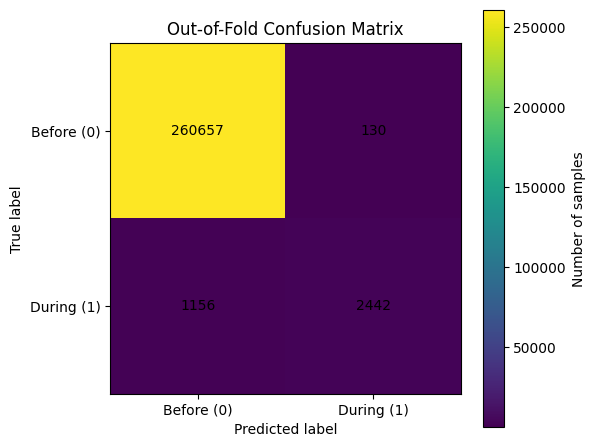

In [ ]:
cm = confusion_matrix(
    y,
    oof_prediction
)

print("\nOOF confusion matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

# Add values inside the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Before (0)",
    "During (1)"
])

ax.set_yticklabels([
    "Before (0)",
    "During (1)"
])

ax.set_title(
    "Out-of-Fold Confusion Matrix"
)

fig.colorbar(
    im,
    ax=ax,
    label="Number of samples"
)

plt.tight_layout()
plt.show()

ROC Curve

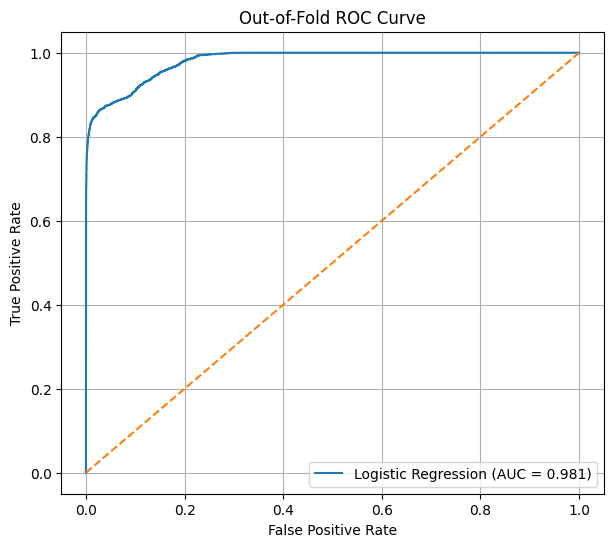

In [ ]:
fpr, tpr, roc_thresholds = roc_curve(
    y,
    oof_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {oof_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Out-of-Fold ROC Curve"
)

plt.legend()
plt.grid(True)

plt.show()

Precision-Recall Curve

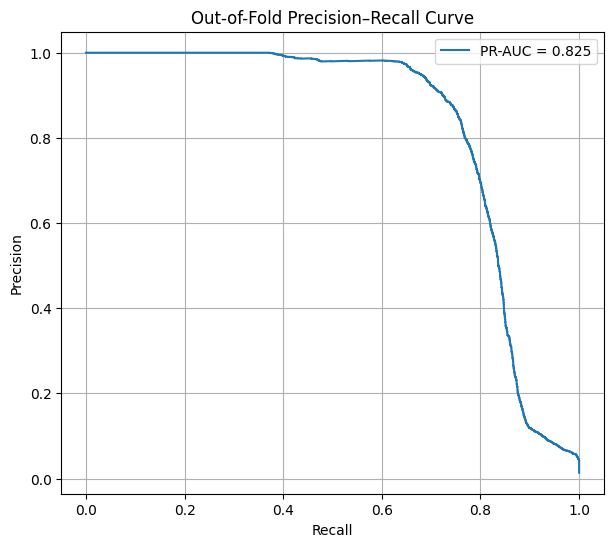

In [ ]:
precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y,
        oof_probability
    )
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {oof_pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Out-of-Fold Precision–Recall Curve"
)

plt.legend()
plt.grid(True)

plt.show()

Classification Report

In [ ]:
print("\nClassification report:")

print(
    classification_report(
        y,
        oof_prediction,
        target_names=[
            "Before instability (0)",
            "During instability (1)"
        ],
        zero_division=0
    )
)


Classification report:
                        precision    recall  f1-score   support

Before instability (0)       1.00      1.00      1.00    260787
During instability (1)       0.95      0.68      0.79      3598

              accuracy                           1.00    264385
             macro avg       0.97      0.84      0.89    264385
          weighted avg       0.99      1.00      0.99    264385



Calibration

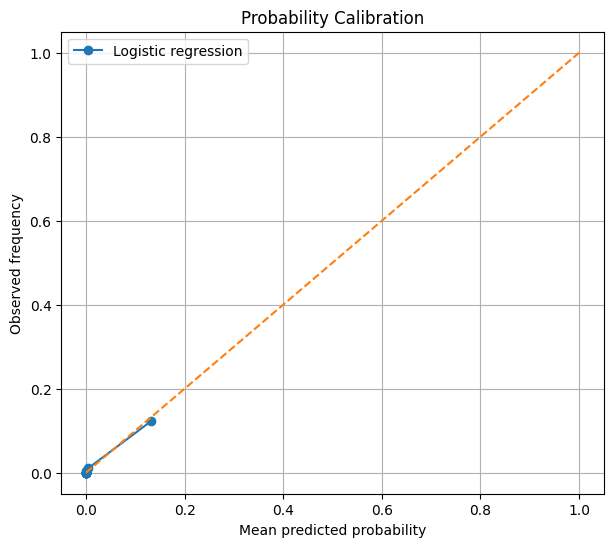

In [ ]:
prob_true, prob_pred = calibration_curve(
    y,
    oof_probability,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")

plt.title(
    "Probability Calibration"
)

plt.legend()
plt.grid(True)

plt.show()

Fit Final Model

After the nested CV evaluation is finished, we can fit the final model on ALL available data.

Importantly, this model is NOT used for estimating the cross-validation performance above.

In [ ]:
final_grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=outer_cv,
    n_jobs=-1,
    refit=True
)

final_grid.fit(
    X,
    y,
    groups=groups
)

final_model = final_grid.best_estimator_

print("\nFinal model parameters:")
print(final_grid.best_params_)


Final model parameters:
{'logistic__C': 100.0, 'logistic__class_weight': None}


Logistic Regression Coefficients

In [ ]:
logistic = final_model.named_steps[
    "logistic"
]

coefficients = logistic.coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients),
    "Absolute_Coefficient": np.abs(coefficients)
})

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 70)

display(coefficient_table)


LOGISTIC REGRESSION COEFFICIENTS


,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
3,plasma_current,-3.840862,0.021475,3.840862
0,density,3.007762,20.242043,3.007762
4,toroidal_B_field,1.844885,6.327372,1.844885
2,minor_radius,-0.452719,0.635897,0.452719
1,elongation,-0.317483,0.727979,0.317483
5,triangularity,-0.106246,0.899204,0.106246


Coefficient Plot

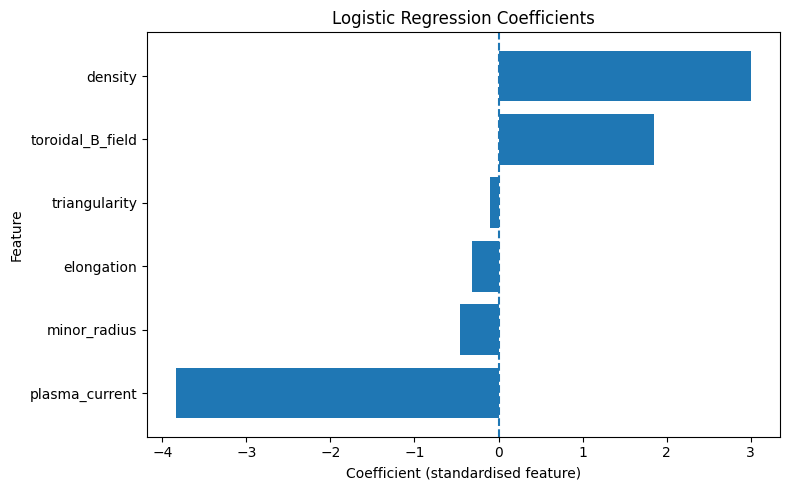

In [ ]:
plot_df = (
    coefficient_table
    .sort_values("Coefficient")
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Coefficient (standardised feature)"
)

plt.ylabel("Feature")

plt.title(
    "Logistic Regression Coefficients"
)

plt.tight_layout()

plt.show()

# Neural Network-based Classification

Imports

In [ ]:
import copy
import random
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    classification_report,
)
from sklearn.calibration import calibration_curve

import joblib

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch: 2.11.0+cpu
CUDA available: False
Device: cpu


Configurations and Data Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FILE_PATH = "/content/drive/MyDrive/Plasma Density Limit Dataset/Open_Density_Limit_Dataset.csv"

RANDOM_STATE = 42
N_OUTER_SPLITS = 5
N_INNER_SPLITS = 2

FEATURES = [
    "density",
    "elongation",
    "minor_radius",
    "plasma_current",
    "toroidal_B_field",
    "triangularity",
]

TARGET = "density_limit_phase"
GROUP = "discharge_ID"
TIME = "time"

# Training configuration
BATCH_SIZE = 2048
MAX_EPOCHS = 80
PATIENCE = 10
MIN_DELTA = 1e-4

# Keep this grid intentionally compact.
HIDDEN_CONFIGS = [
    (64, 32),
    (128, 64),
    (64, 32, 16),
]

DROPOUT_VALUES = [0.0, 0.2]
LEARNING_RATES = [1e-3, 3e-4]
WEIGHT_DECAYS = [1e-4, 1e-3]
USE_CLASS_WEIGHTS = [False, True]

# For initial development, use a smaller grid.
# The full grid has 48 combinations and can be computationally expensive.

Load and clean the data

In [ ]:
data = pd.read_csv(FILE_PATH)

required_columns = FEATURES + [TARGET, GROUP, TIME]
missing_columns = [c for c in required_columns if c not in data.columns]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

for col in FEATURES + [TARGET, TIME]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna(subset=FEATURES + [TARGET, GROUP, TIME]).copy()

data = data[data[TARGET].isin([0, 1])].copy()
data[TARGET] = data[TARGET].astype(int)

data = data.reset_index(drop=True)

X = data[FEATURES].astype(np.float32)
y = data[TARGET].astype(int)
groups = data[GROUP]

print("Rows:", len(data))
print("Discharges:", groups.nunique())
print("\nClass distribution:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))

Rows: 264385
Discharges: 2333

Class distribution:
density_limit_phase
0    260787
1      3598
Name: count, dtype: int64

Class proportions:
density_limit_phase
0    0.986391
1    0.013609
Name: proportion, dtype: float64


Check if the dataset has enough positive and negative discharges to support five outer folds

In [ ]:
discharge_class_counts = (
    data.groupby(GROUP)[TARGET]
    .agg(lambda x: set(x.unique()))
)

print("Discharges containing class 0:",
      sum(0 in s for s in discharge_class_counts))
print("Discharges containing class 1:",
      sum(1 in s for s in discharge_class_counts))

Discharges containing class 0: 2328
Discharges containing class 1: 78


In [ ]:
outer_cv = StratifiedGroupKFold(
    n_splits=N_OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

outer_splits = list(outer_cv.split(X, y, groups))

for fold, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])

    assert train_groups.isdisjoint(test_groups)

    print(
        f"Fold {fold}: "
        f"train rows={len(train_idx):,}, "
        f"test rows={len(test_idx):,}, "
        f"train positive rate={y.iloc[train_idx].mean():.4f}, "
        f"test positive rate={y.iloc[test_idx].mean():.4f}, "
        f"test discharges={len(test_groups)}"
    )

Fold 1: train rows=211,819, test rows=52,566, train positive rate=0.0130, test positive rate=0.0159, test discharges=464
Fold 2: train rows=211,140, test rows=53,245, train positive rate=0.0127, test positive rate=0.0173, test discharges=467
Fold 3: train rows=211,816, test rows=52,569, train positive rate=0.0149, test positive rate=0.0082, test discharges=465
Fold 4: train rows=211,274, test rows=53,111, train positive rate=0.0142, test positive rate=0.0114, test discharges=468
Fold 5: train rows=211,491, test rows=52,894, train positive rate=0.0132, test positive rate=0.0152, test discharges=469


The Neural Network

In [ ]:
class DensityLimitMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)

The Training Function

The training function below uses early stopping on validation loss. It restores the best validation-loss model rather than keeping the weights from the final epoch.

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_loader(X_array, y_array, batch_size, shuffle):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.float32)

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)

    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )


def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    learning_rate,
    weight_decay,
    pos_weight=None,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
):
    if pos_weight is not None:
        loss_fn = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(
                [pos_weight], dtype=torch.float32, device=DEVICE
            )
        )
    else:
        loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_val_loss = np.inf
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                val_loss = loss_fn(logits, yb)
                val_losses.append(val_loss.item())

        mean_val_loss = float(np.mean(val_losses))

        if mean_val_loss < best_val_loss - min_delta:
            best_val_loss = mean_val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_epoch, best_val_loss


def predict_probabilities(model, X_array):
    model.eval()

    X_tensor = torch.tensor(
        X_array, dtype=torch.float32
    )

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tensor),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    probabilities = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits)
            probabilities.extend(probs.cpu().numpy())

    return np.asarray(probabilities)

Hyperparameter search

In [ ]:
CANDIDATES = [
    {
        "hidden_layers": (32, 16),
        "dropout": 0.0,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "use_class_weights": False,
    },
    {
        "hidden_layers": (64, 32),
        "dropout": 0.2,
        "learning_rate": 1e-3,
        "weight_decay": 1e-3,
        "use_class_weights": False,
    },
    {
        "hidden_layers": (64, 32),
        "dropout": 0.2,
        "learning_rate": 3e-4,
        "weight_decay": 1e-3,
        "use_class_weights": True,
    },
]

In [ ]:
def fit_candidate_on_inner_split(
    X_train_outer,
    y_train_outer,
    groups_train_outer,
    inner_train_idx,
    inner_val_idx,
    candidate,
    seed,
):
    X_inner_train = X_train_outer.iloc[inner_train_idx]
    y_inner_train = y_train_outer.iloc[inner_train_idx]
    g_inner_train = groups_train_outer.iloc[inner_train_idx]

    X_inner_val = X_train_outer.iloc[inner_val_idx]
    y_inner_val = y_train_outer.iloc[inner_val_idx]

    # Create a grouped early-stopping split inside inner training.
    early_cv = StratifiedGroupKFold(
        n_splits=4,
        shuffle=True,
        random_state=seed
    )

    early_train_idx, early_stop_idx = next(
        early_cv.split(X_inner_train, y_inner_train, g_inner_train)
    )

    X_fit = X_inner_train.iloc[early_train_idx]
    y_fit = y_inner_train.iloc[early_train_idx]

    X_early = X_inner_train.iloc[early_stop_idx]
    y_early = y_inner_train.iloc[early_stop_idx]

    # Fit preprocessing on gradient-training data only.
    scaler = StandardScaler()
    X_fit_scaled = scaler.fit_transform(X_fit)
    X_early_scaled = scaler.transform(X_early)
    X_inner_val_scaled = scaler.transform(X_inner_val)

    # Optional positive-class weighting, using gradient-training labels only.
    pos_weight = None
    if candidate["use_class_weights"]:
        n_positive = int((y_fit == 1).sum())
        n_negative = int((y_fit == 0).sum())

        if n_positive == 0:
            raise ValueError("No positive samples in model-training subset.")

        pos_weight = n_negative / n_positive

    train_loader = make_loader(
        X_fit_scaled,
        y_fit.to_numpy(),
        BATCH_SIZE,
        shuffle=True
    )

    early_loader = make_loader(
        X_early_scaled,
        y_early.to_numpy(),
        BATCH_SIZE,
        shuffle=False
    )

    set_seed(seed)

    model = DensityLimitMLP(
        input_dim=X_fit_scaled.shape[1],
        hidden_layers=candidate["hidden_layers"],
        dropout=candidate["dropout"]
    ).to(DEVICE)

    model, best_epoch, best_val_loss = train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=early_loader,
        learning_rate=candidate["learning_rate"],
        weight_decay=candidate["weight_decay"],
        pos_weight=pos_weight
    )

    inner_val_prob = predict_probabilities(model, X_inner_val_scaled)

    return inner_val_prob, best_epoch

Nested grouped CV

In [ ]:
def fit_fixed_epochs(
    X_train,
    y_train,
    candidate,
    epochs,
    seed
):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    pos_weight = None
    if candidate["use_class_weights"]:
        n_positive = int((y_train == 1).sum())
        n_negative = int((y_train == 0).sum())
        pos_weight = n_negative / n_positive

    train_loader = make_loader(
        X_train_scaled,
        y_train.to_numpy(),
        BATCH_SIZE,
        shuffle=True
    )

    set_seed(seed)

    model = DensityLimitMLP(
        input_dim=X_train_scaled.shape[1],
        hidden_layers=candidate["hidden_layers"],
        dropout=candidate["dropout"]
    ).to(DEVICE)

    if pos_weight is not None:
        loss_fn = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(
                [pos_weight], dtype=torch.float32, device=DEVICE
            )
        )
    else:
        loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=candidate["learning_rate"],
        weight_decay=candidate["weight_decay"]
    )

    for epoch in range(epochs):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

    return model, scaler


def safe_average_precision(y_true, probabilities):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, probabilities)


oof_probability = np.full(len(data), np.nan)
oof_prediction = np.full(len(data), np.nan)

outer_results = []
candidate_results = []
outer_models = []

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer_splits, start=1
):
    print(f"\n{'='*60}")
    print(f"OUTER FOLD {outer_fold}/{N_OUTER_SPLITS}")
    print(f"{'='*60}")

    X_train = X.iloc[outer_train_idx].reset_index(drop=True)
    y_train = y.iloc[outer_train_idx].reset_index(drop=True)
    g_train = groups.iloc[outer_train_idx].reset_index(drop=True)

    X_test = X.iloc[outer_test_idx]
    y_test = y.iloc[outer_test_idx]

    inner_cv = StratifiedGroupKFold(
        n_splits=N_INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + outer_fold
    )

    inner_splits = list(inner_cv.split(X_train, y_train, g_train))

    scores_by_candidate = []
    epochs_by_candidate = []

    for candidate_id, candidate in enumerate(CANDIDATES):
        inner_scores = []
        inner_epochs = []

        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(
            inner_splits, start=1
        ):
            y_inner_val = y_train.iloc[inner_val_idx].to_numpy()

            if len(np.unique(y_inner_val)) < 2:
                inner_scores.append(np.nan)
                continue

            probabilities, best_epoch = fit_candidate_on_inner_split(
                X_train_outer=X_train,
                y_train_outer=y_train,
                groups_train_outer=g_train,
                inner_train_idx=inner_train_idx,
                inner_val_idx=inner_val_idx,
                candidate=candidate,
                seed=RANDOM_STATE + 1000 * outer_fold
                     + 100 * candidate_id + inner_fold
            )

            score = average_precision_score(
                y_inner_val,
                probabilities
            )

            inner_scores.append(score)
            inner_epochs.append(best_epoch)

        mean_score = (
            float(np.nanmean(inner_scores))
            if not np.all(np.isnan(inner_scores))
            else np.nan
        )

        median_epochs = (
            int(np.median(inner_epochs))
            if len(inner_epochs) > 0
            else 1
        )

        scores_by_candidate.append(mean_score)
        epochs_by_candidate.append(median_epochs)

        candidate_results.append({
            "Outer_Fold": outer_fold,
            "Candidate_ID": candidate_id,
            "Candidate": candidate,
            "Mean_Inner_AP": mean_score,
            "Median_Best_Epoch": median_epochs
        })

        print(
            f"Candidate {candidate_id + 1}/{len(CANDIDATES)} | "
            f"inner AP={mean_score:.4f} | "
            f"epochs={median_epochs}"
        )

    if np.all(np.isnan(scores_by_candidate)):
        raise ValueError(
            f"All candidates failed to produce valid inner scores "
            f"in outer fold {outer_fold}."
        )

    best_candidate_idx = int(np.nanargmax(scores_by_candidate))
    best_candidate = CANDIDATES[best_candidate_idx]
    selected_epochs = max(1, epochs_by_candidate[best_candidate_idx])

    print("\nSelected candidate:", best_candidate)
    print("Selected epochs:", selected_epochs)

    # Refit on all outer-training data.
    model, scaler = fit_fixed_epochs(
        X_train=X_train,
        y_train=y_train,
        candidate=best_candidate,
        epochs=selected_epochs,
        seed=RANDOM_STATE + 5000 + outer_fold
    )

    X_test_scaled = scaler.transform(X_test)
    test_probabilities = predict_probabilities(model, X_test_scaled)
    test_predictions = (test_probabilities >= 0.5).astype(int)

    oof_probability[outer_test_idx] = test_probabilities
    oof_prediction[outer_test_idx] = test_predictions

    outer_models.append({
        "model": model,
        "scaler": scaler,
        "candidate": best_candidate,
        "epochs": selected_epochs,
        "outer_fold": outer_fold
    })

    outer_results.append({
        "Fold": outer_fold,
        "ROC_AUC": (
            roc_auc_score(y_test, test_probabilities)
            if y_test.nunique() == 2 else np.nan
        ),
        "PR_AUC": safe_average_precision(
            y_test.to_numpy(), test_probabilities
        ),
        "Accuracy": accuracy_score(y_test, test_predictions),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_test, test_predictions
        ),
        "Precision": precision_score(
            y_test, test_predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, test_predictions, zero_division=0
        ),
        "F1": f1_score(
            y_test, test_predictions, zero_division=0
        ),
        "Brier_Score": brier_score_loss(
            y_test, test_probabilities
        ),
        "Selected_Epochs": selected_epochs,
        "Selected_Candidate": best_candidate_idx
    })

    print("Outer-fold PR-AUC:",
          outer_results[-1]["PR_AUC"])
    print("Outer-fold ROC-AUC:",
          outer_results[-1]["ROC_AUC"])


OUTER FOLD 1/5
Candidate 1/3 | inner AP=0.8940 | epochs=72
Candidate 2/3 | inner AP=0.8681 | epochs=47
Candidate 3/3 | inner AP=0.8526 | epochs=34

Selected candidate: {'hidden_layers': (32, 16), 'dropout': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'use_class_weights': False}
Selected epochs: 72
Outer-fold PR-AUC: 0.9810774522790793
Outer-fold ROC-AUC: 0.9995862071836005

OUTER FOLD 2/5
Candidate 1/3 | inner AP=0.9183 | epochs=78
Candidate 2/3 | inner AP=0.8762 | epochs=56
Candidate 3/3 | inner AP=0.9107 | epochs=56

Selected candidate: {'hidden_layers': (32, 16), 'dropout': 0.0, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'use_class_weights': False}
Selected epochs: 78
Outer-fold PR-AUC: 0.9765181543414021
Outer-fold ROC-AUC: 0.9994385010074992

OUTER FOLD 3/5
Candidate 1/3 | inner AP=0.9022 | epochs=55
Candidate 2/3 | inner AP=0.8768 | epochs=39
Candidate 3/3 | inner AP=0.9332 | epochs=79

Selected candidate: {'hidden_layers': (64, 32), 'dropout': 0.2, 'learning_rate'

Evaluate the out-of-fold predictions

In [ ]:
outer_results_df = pd.DataFrame(outer_results)

metric_columns = [
    "ROC_AUC",
    "PR_AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Brier_Score"
]

print("Outer-fold results:")
display(outer_results_df)

print("\nMean ± standard deviation across outer folds:")
for metric in metric_columns:
    mean_value = outer_results_df[metric].mean()
    std_value = outer_results_df[metric].std()
    print(f"{metric}: {mean_value:.4f} ± {std_value:.4f}")

Outer-fold results:


,Fold,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Brier_Score,Selected_Epochs,Selected_Candidate
0,1,0.999586,0.981077,0.997698,0.958229,0.936508,0.917464,0.926888,0.001746,72,0
1,2,0.999439,0.976518,0.996356,0.903108,0.978892,0.806522,0.884386,0.002678,78,0
2,3,0.996912,0.954748,0.994445,0.985748,0.600000,0.976905,0.743409,0.004380,79,2
3,4,0.998552,0.906252,0.996893,0.940330,0.850080,0.882450,0.865963,0.002580,79,0
4,5,0.999759,0.987101,0.988657,0.993629,0.573058,0.998758,0.728261,0.008402,79,2



Mean ± standard deviation across outer folds:
ROC_AUC: 0.9988 ± 0.0012
PR_AUC: 0.9611 ± 0.0330
Accuracy: 0.9948 ± 0.0036
Balanced_Accuracy: 0.9562 ± 0.0366
Precision: 0.7877 ± 0.1897
Recall: 0.9164 ± 0.0769
F1: 0.8298 ± 0.0887
Brier_Score: 0.0040 ± 0.0027


Calculate pooled OOF metrics

In [ ]:
valid = ~np.isnan(oof_probability)

y_oof = y.to_numpy()[valid]
prob_oof = oof_probability[valid]
pred_oof = oof_prediction[valid].astype(int)

print("OOF observations:", len(y_oof), "of", len(y))

oof_metrics = {
    "ROC_AUC": (
        roc_auc_score(y_oof, prob_oof)
        if len(np.unique(y_oof)) == 2 else np.nan
    ),
    "PR_AUC": safe_average_precision(y_oof, prob_oof),
    "Accuracy": accuracy_score(y_oof, pred_oof),
    "Balanced_Accuracy": balanced_accuracy_score(y_oof, pred_oof),
    "Precision": precision_score(y_oof, pred_oof, zero_division=0),
    "Recall": recall_score(y_oof, pred_oof, zero_division=0),
    "F1": f1_score(y_oof, pred_oof, zero_division=0),
    "Brier_Score": brier_score_loss(y_oof, prob_oof)
}

print("\nPooled OOF metrics:")
for name, value in oof_metrics.items():
    print(f"{name}: {value:.4f}")

OOF observations: 264385 of 264385

Pooled OOF metrics:
ROC_AUC: 0.9982
PR_AUC: 0.9251
Accuracy: 0.9948
Balanced_Accuracy: 0.9523
Precision: 0.7581
Recall: 0.9086
F1: 0.8265
Brier_Score: 0.0040


Specificity and the confusion matrix

Confusion matrix:
[[259744   1043]
 [   329   3269]]
Specificity: 0.9960


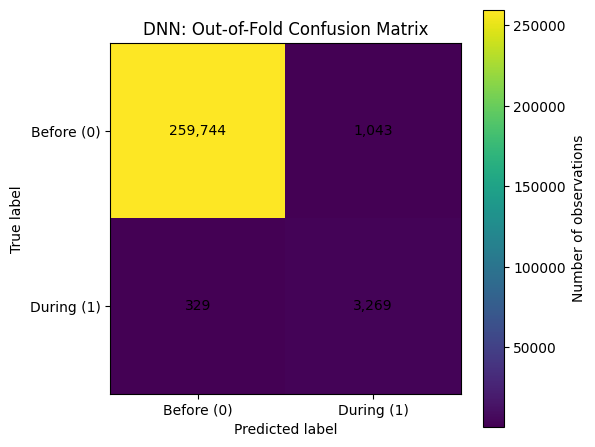

              precision    recall  f1-score   support

  Before (0)       1.00      1.00      1.00    260787
  During (1)       0.76      0.91      0.83      3598

    accuracy                           0.99    264385
   macro avg       0.88      0.95      0.91    264385
weighted avg       1.00      0.99      1.00    264385



In [ ]:
cm = confusion_matrix(y_oof, pred_oof, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

print("Confusion matrix:")
print(cm)
print(f"Specificity: {specificity:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Before (0)", "During (1)"])
ax.set_yticklabels(["Before (0)", "During (1)"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("DNN: Out-of-Fold Confusion Matrix")
fig.colorbar(im, ax=ax, label="Number of observations")
plt.tight_layout()
plt.show()

print(classification_report(
    y_oof,
    pred_oof,
    labels=[0, 1],
    target_names=["Before (0)", "During (1)"],
    zero_division=0
))

ROC, precision–recall, and calibration curves

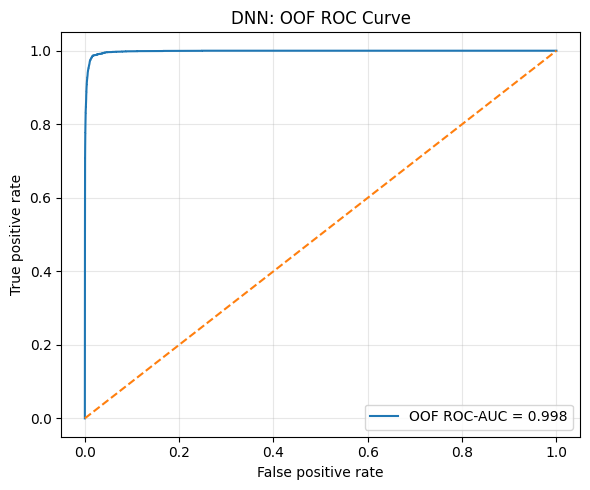

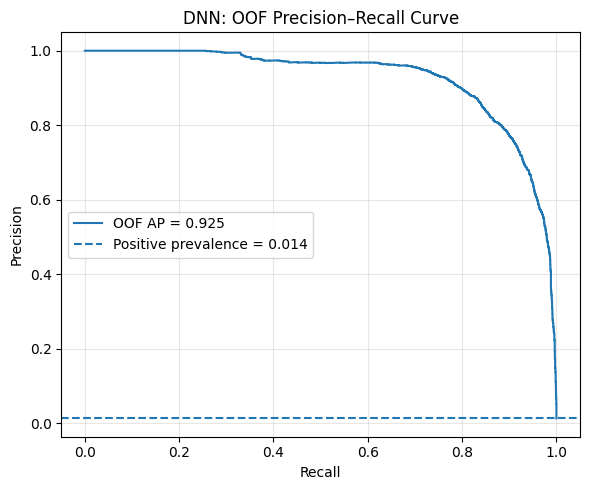

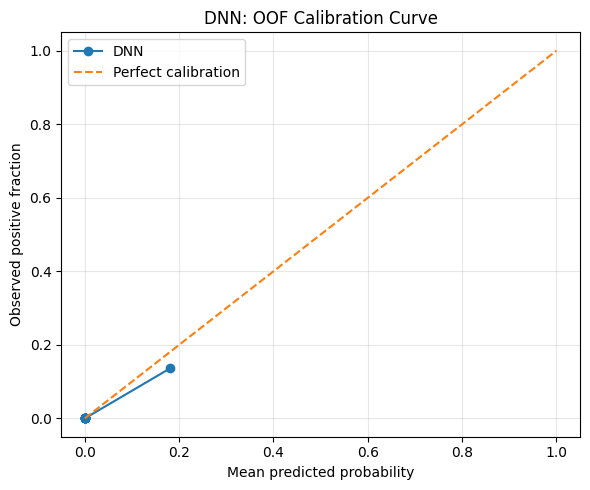

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_oof, prob_oof)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"OOF ROC-AUC = {oof_metrics['ROC_AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("DNN: OOF ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_oof, prob_oof)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"OOF AP = {oof_metrics['PR_AUC']:.3f}")
plt.axhline(
    y=np.mean(y_oof),
    linestyle="--",
    label=f"Positive prevalence = {np.mean(y_oof):.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("DNN: OOF Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Calibration curve
fraction_positive, mean_predicted = calibration_curve(
    y_oof,
    prob_oof,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 5))
plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    label="DNN"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive fraction")
plt.title("DNN: OOF Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Threshold analysis

The threshold of 0.5 is useful as a fixed primary benchmark, but it is not necessarily the best operating point for a plasma monitoring application. Examine the sensitivity–specificity trade-off without using the outer test labels to select a threshold

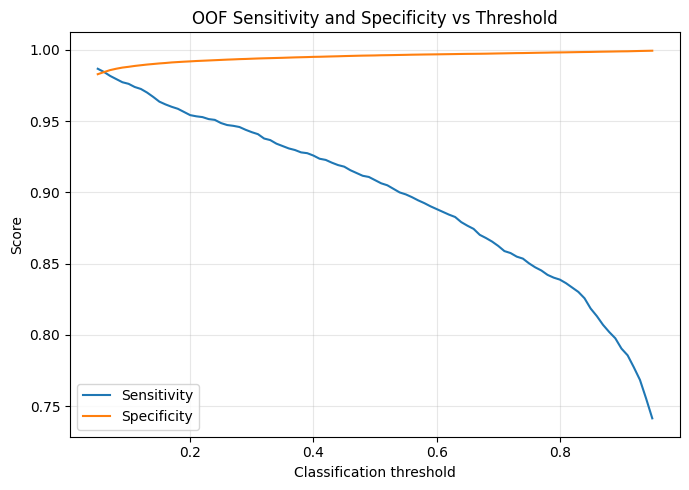

In [ ]:
thresholds = np.linspace(0.05, 0.95, 91)

threshold_results = []

for threshold in thresholds:
    predictions = (prob_oof >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_oof, predictions, labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    threshold_results.append({
        "Threshold": threshold,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision_score(
            y_oof, predictions, zero_division=0
        ),
        "F1": f1_score(y_oof, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(7, 5))
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Sensitivity"],
    label="Sensitivity"
)
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Specificity"],
    label="Specificity"
)
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("OOF Sensitivity and Specificity vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Compare with logistic regression

In [ ]:
comparison = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Brier Score"
    ],
    "Logistic Regression": [
        # Insert your logistic regression pooled OOF values here.
        0.9811, 0.8247, 0.9951, 0.8391,
        0.9495, 0.6787, 0.7916, 0.0042
    ],
    "DNN": [
        oof_metrics["ROC_AUC"],
        oof_metrics["PR_AUC"],
        oof_metrics["Accuracy"],
        oof_metrics["Balanced_Accuracy"],
        oof_metrics["Precision"],
        oof_metrics["Recall"],
        oof_metrics["F1"],
        oof_metrics["Brier_Score"]
    ]
})

display(comparison)

,Metric,Logistic Regression,DNN
0,ROC-AUC,0.9811,0.998223
1,PR-AUC,0.8247,0.925141
2,Accuracy,0.9951,0.994811
3,Balanced Accuracy,0.8391,0.952280
4,Precision,0.9495,0.758117
5,Recall,0.6787,0.908560
6,F1,0.7916,0.826549
7,Brier Score,0.0042,0.003957
